<a href="https://colab.research.google.com/github/7yl4r/HabEvent/blob/main/HabEventS2SeagrassStAndrews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This script:

* pulls data that was extracted from Sentinel-2 ImageCollection in GEE [[example script](https://code.earthengine.google.com/?scriptPath=users%2Ftylarmurray%2Fst-andrews-bay%3Aseagrass_time_series_extraction)]
* Calculates Seagrass Indices From the Band Values
* Subtracts the "reference region" from the "area of interest" to remove atmosphere/water effects
* converts index values into z-scores so they fit on the same plot
* performs seasonal decomposition on z-scored, differenced, indices
* Plots resulting season, trend, and residuals

In [ ]:
interestRegionExtractionURL = "https://raw.githubusercontent.com/7yl4r/HabEvent/refs/heads/main/aoi-extractions/ccf_phase_1_resto.csv"
referenceRegionExtractionURL = "https://raw.githubusercontent.com/7yl4r/HabEvent/refs/heads/main/aoi-extractions/ccf_phase_1_resto_reference_region.csv"

In [ ]:
# csv fetching function
import pandas as pd
import urllib.request
from io import StringIO

def extract_and_clean_region_data(url):
    """
    Fetches CSV data from a URL, parses dates, and cleans empty band rows.
    """
    # Fetch the CSV
    with urllib.request.urlopen(url) as response:
        csv_text = response.read().decode("utf-8")

    # Parse CSV
    df = pd.read_csv(StringIO(csv_text))

    # Parse dates and set as index
    if "system:time_start" in df.columns:
        df["system:time_start"] = pd.to_datetime(df["system:time_start"])
        df = df.set_index("system:time_start").sort_index()

    return df

# Example usage:
# df_final = extract_and_clean_region_data(interestRegionExtractionURL)

In [ ]:
# ==============================================================================
# === Add Indicies To DataFrame
# ==============================================================================
SEAGRASS_INDICES = ['WAVI', '~NDSVI', 'red_edge1_red_ratio', 'ND_red_edge1_red']
def add_seagrass_indices(df):
    """
    Calculates specific indices based on B# band columns and adds them to the DataFrame.
    """
    # Create a copy to avoid SettingWithCopy warnings
    df = df.copy()

    # WAVI: (B8-B2)/(B8+B2)
    df['WAVI'] = (df['B8'] - df['B2']) / (df['B8'] + df['B2'])

    # #  NDSVI: (B2-B3)/(B2+B3)
    #  df['NDSVI'] = (df['B2'] - df['B3']) / (df['B2'] + df['B3'])
    # ~NDSVI: (B3-B2)/(B3+B2)
    df['~NDSVI'] = (df['B3'] - df['B2']) / (df['B3'] + df['B2'])

    # red_edge1/red: B5/B4
    df['red_edge1_red_ratio'] = df['B5'] / df['B4']

    # Normalized Difference red_edge1-red: (B5-B4)/(B5+B4)
    df['ND_red_edge1_red'] = (df['B5'] - df['B4']) / (df['B5'] + df['B4'])

    return df


def convert_to_zscores(df, indices):
    """
    Calculates Z-scores for specific index columns and adds them as new columns.
    Formula: (value - mean) / standard deviation
    """
    # Create a copy to avoid SettingWithCopy warnings
    df = df.copy()

    for col in indices:
        if col in df.columns:
            # Calculate mean and standard deviation
            mean_val = df[col].mean()
            std_val = df[col].std()

            # Apply Z-score calculation: (x - μ) / σ
            # Using pandas vectorized operations for efficiency
            # Overwriting the original column with the z-score result
            df[col] = (df[col] - mean_val) / std_val

    return df

# Example usage:
# df_zscored = convert_to_zscores(df_with_indices, SEAGRASS_INDICES)



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

def plot_split_violins(df1, df2, label1="Interest Region", label2="Reference Region",
                        cols=None, figsize=None, palette=("#2E86AB", "#E84855")):
    """
    Split-violin plot comparing each column of two DataFrames.

    Parameters
    ----------
    df1, df2    : DataFrames to compare (must share column names)
    label1/2    : Legend labels for each DataFrame
    cols        : List of columns to plot (defaults to shared numeric columns)
    figsize     : Figure size tuple; auto-calculated if None
    palette     : Two-color tuple for (df1, df2)
    """
    # --- column selection ---
    shared = list(df1.select_dtypes(include="number").columns.intersection(
                  df2.select_dtypes(include="number").columns))
    cols = cols or shared
    if not cols:
        raise ValueError("No shared numeric columns found between the two DataFrames.")

    n = len(cols)
    ncols_plot = min(4, n)
    nrows_plot = (n + ncols_plot - 1) // ncols_plot
    figsize = figsize or (4.5 * ncols_plot, 4 * nrows_plot)

    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=figsize)
    axes = np.array(axes).flatten()

    color1, color2 = palette

    for i, col in enumerate(cols):
        ax = axes[i]
        data1 = df1[col].dropna().values
        data2 = df2[col].dropna().values

        # KDE for each side
        def kde_curve(data, bw_method="scott"):
            kde = stats.gaussian_kde(data, bw_method=bw_method)
            x = np.linspace(min(data.min(), data.min()), max(data.max(), data.max()), 300)
            return x, kde(x)

        all_vals = np.concatenate([data1, data2])
        x_range = np.linspace(all_vals.min(), all_vals.max(), 300)

        kde1 = stats.gaussian_kde(data1)
        kde2 = stats.gaussian_kde(data2)
        y1 = kde1(x_range)
        y2 = kde2(x_range)

        # Normalize to same max width
        max_density = max(y1.max(), y2.max())
        y1_norm = y1 / max_density * 0.4
        y2_norm = y2 / max_density * 0.4

        # Left half = df1, Right half = df2
        ax.fill_betweenx(x_range, -y1_norm, 0, alpha=0.75, color=color1)
        ax.fill_betweenx(x_range, 0, y2_norm,  alpha=0.75, color=color2)
        ax.plot(-y1_norm, x_range, color=color1, lw=1.2)
        ax.plot(y2_norm,  x_range, color=color2, lw=1.2)

        # Median lines
        for data, sign, color in [(data1, -1, color1), (data2, 1, color2)]:
            med = np.median(data)
            kde_obj = stats.gaussian_kde(data)
            half_w = kde_obj([med])[0] / max_density * 0.4
            ax.hlines(med, sign * half_w * 0.05, sign * half_w,
                      color="white", lw=2, zorder=5)
            ax.hlines(med, sign * half_w * 0.05, sign * half_w,
                      color=color, lw=1, zorder=6, linestyle="--")

        # IQR box (narrow)
        for data, sign, color in [(data1, -1, color1), (data2, 1, color2)]:
            q25, q75 = np.percentile(data, [25, 75])
            ax.fill_betweenx([q25, q75], 0, sign * 0.04,
                             color="white", alpha=0.6, zorder=4)

        ax.axvline(0, color="grey", lw=0.8, linestyle=":")
        ax.set_title(col, fontsize=10, fontweight="bold", pad=6)
        ax.set_xlabel("Density", fontsize=8)
        ax.tick_params(axis="both", labelsize=8)
        ax.set_xlim(-0.55, 0.55)
        ax.set_xticks([])
        ax.spines[["top", "right", "bottom"]].set_visible(False)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Legend
    patches = [
        mpatches.Patch(color=color1, alpha=0.75, label=label1),
        mpatches.Patch(color=color2, alpha=0.75, label=label2),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=2,
               fontsize=10, frameon=False,
               bbox_to_anchor=(0.5, 0.01))

    fig.suptitle("Split-Violin Comparison", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("split_violin_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fig




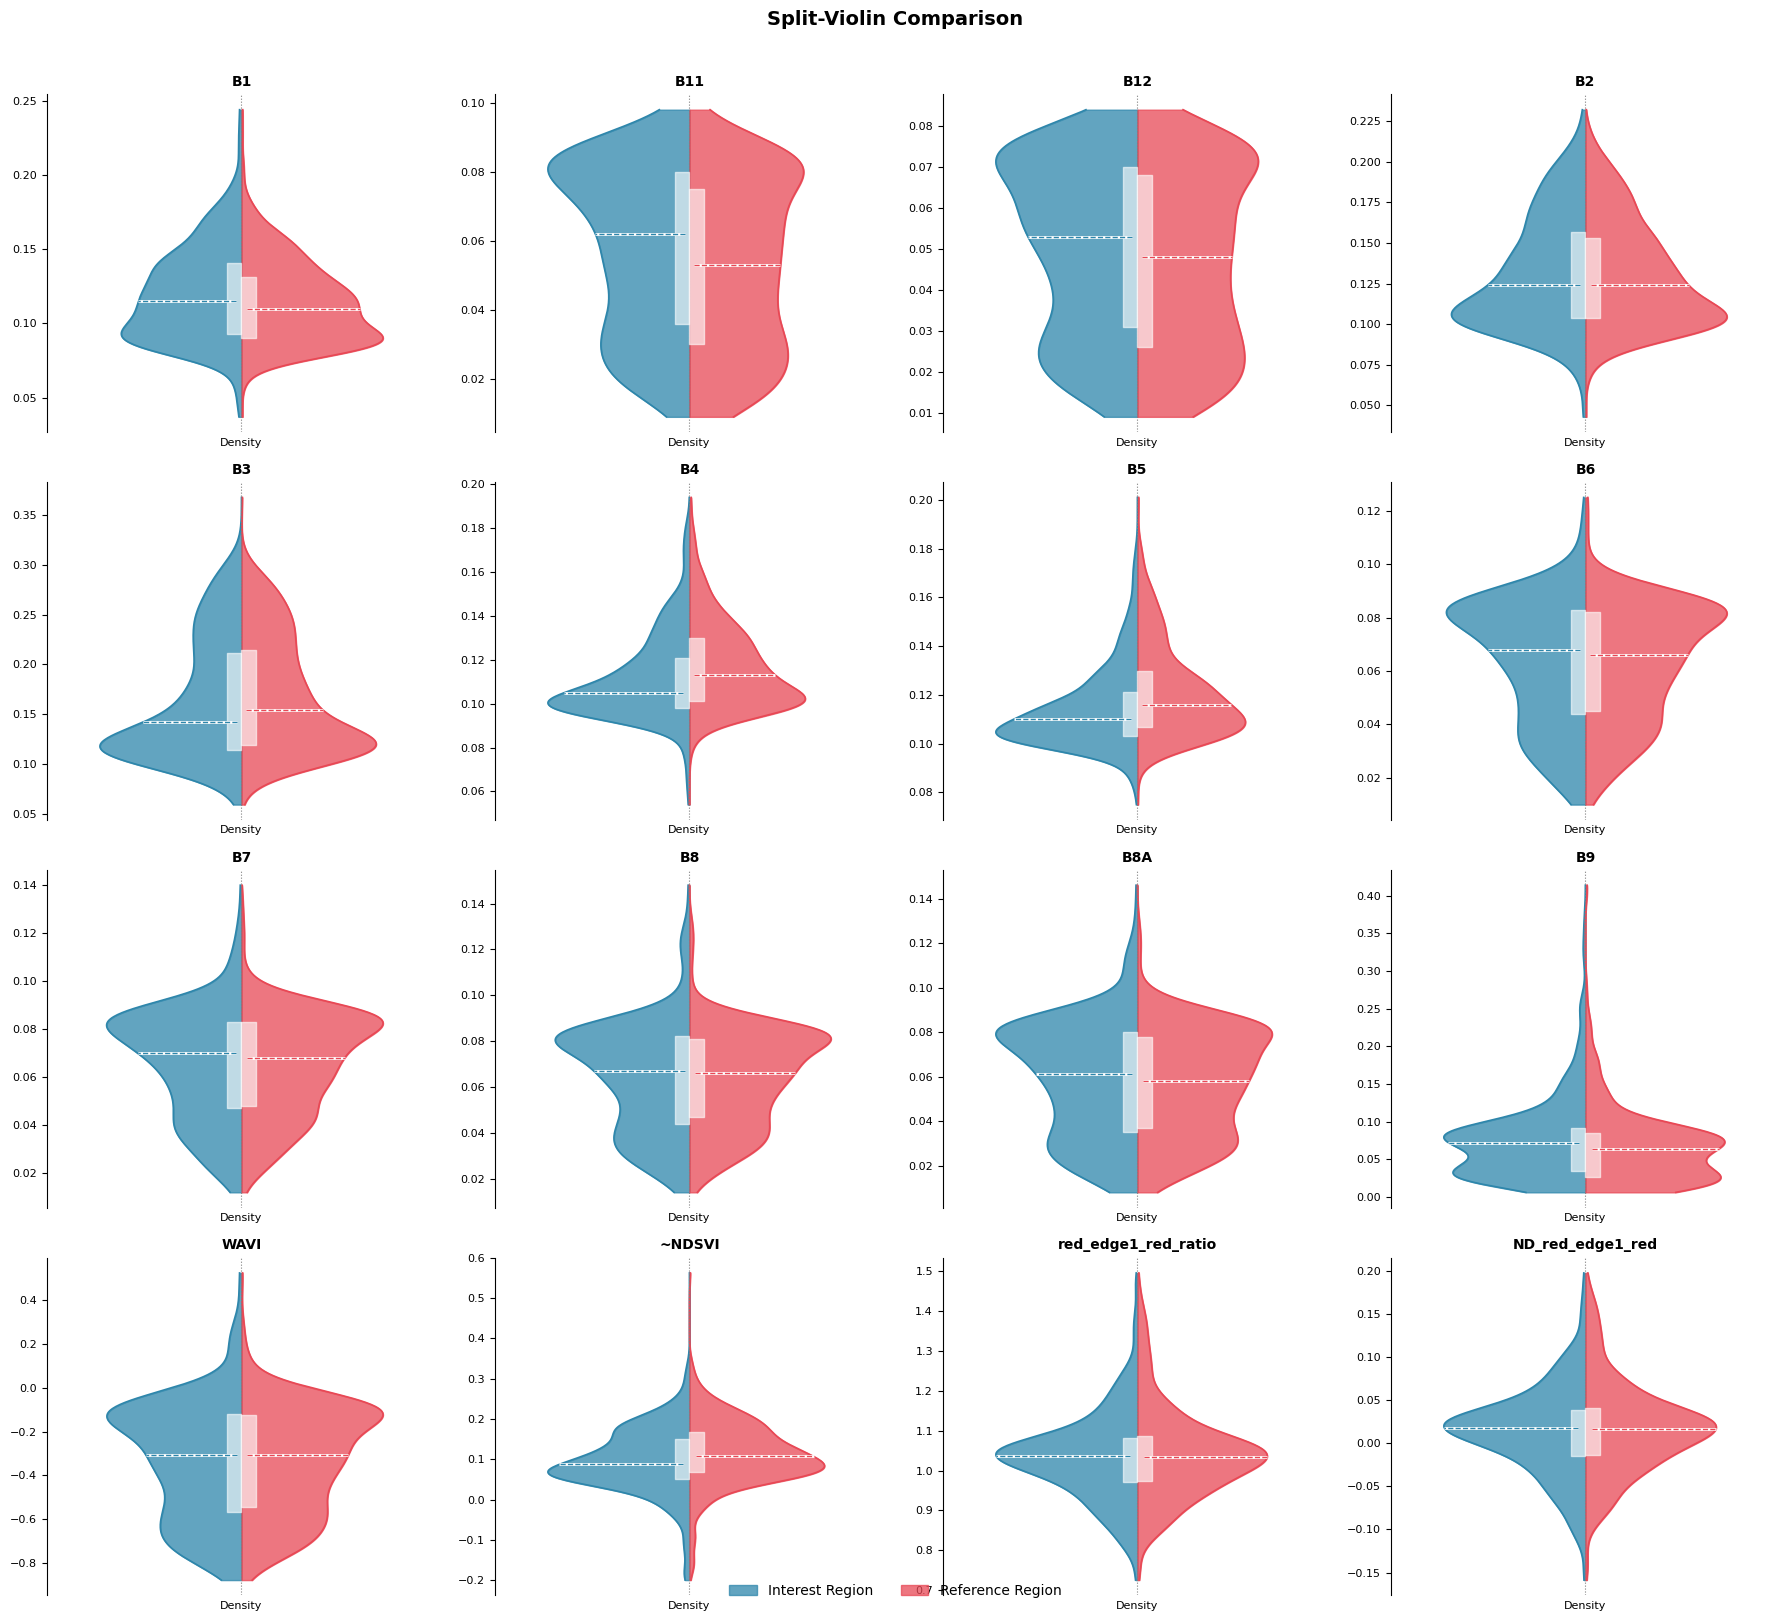

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO
import urllib.request

# Fetch the CSVs
df_interestRegion = add_seagrass_indices(
    extract_and_clean_region_data(interestRegionExtractionURL)
)
df_referenceRegion = add_seagrass_indices(
    extract_and_clean_region_data(referenceRegionExtractionURL)
)

# Violin plot for each band to compare statistics from regions
# --- Usage ---
plot_split_violins(
    df_interestRegion,
    df_referenceRegion,
    label1="Interest Region",
    label2="Reference Region",
)

# ==============================================================================
# === Adjust using Reference Region as a Baseline
# ==============================================================================
# Note: This assumes both DataFrames share the same index (system:time_start).
# Pandas will automatically align rows based on the index.

# Create a new DataFrame for the differences
## subtraction
df_diff = df_interestRegion[SEAGRASS_INDICES] - df_referenceRegion[SEAGRASS_INDICES]
### division
# df_diff = df_interestRegion[SEAGRASS_INDICES] / (df_referenceRegion[SEAGRASS_INDICES] + 0.000000000000000001)

# ==============================================================================
# ==============================================================================
# === convert differences to z scores
# ==============================================================================
df_diff_zscores = convert_to_zscores(df_diff, SEAGRASS_INDICES)
# ==============================================================================



S2 Referece-Region-Corrected Seagrass Indices zscores


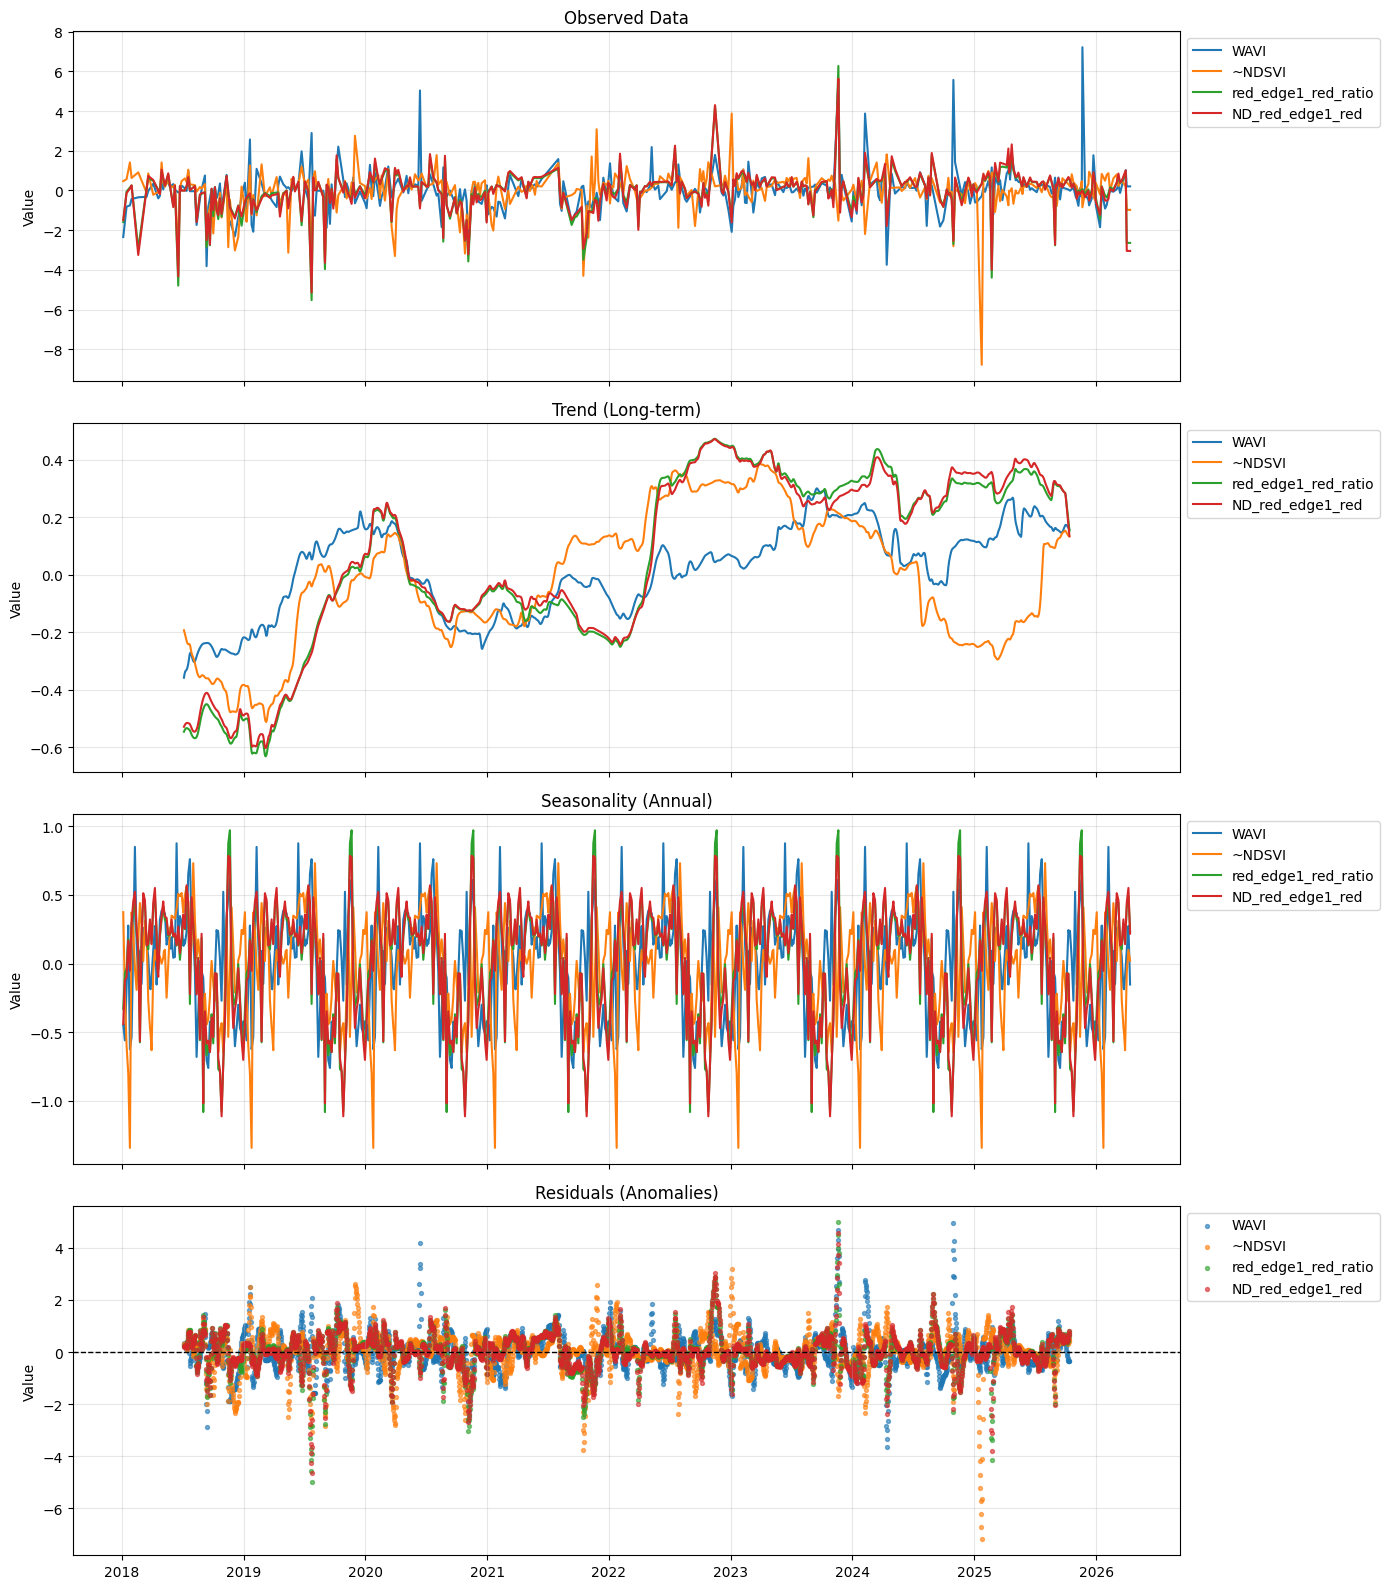

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_combined_seasonal_decomposition(df, indices, resample_freq='D', period=365):
    """
    Performs seasonal decomposition on multiple indices and plots them together
    on shared axes for comparison.
    """
    # Create a copy and ensure index is datetime
    df_decomp = df.copy()
    if not isinstance(df_decomp.index, pd.DatetimeIndex):
        df_decomp.index = pd.to_datetime(df_decomp.index)

    df_decomp = df_decomp.sort_index()

    # Dictionary to store decomposition results
    results = {}

    for col in indices:
        if col in df_decomp.columns:
            # 1. Resample and interpolate missing values
            # Decomposition requires a fixed frequency
            series = df_decomp[col].resample(resample_freq).mean().interpolate(method='time')
            series = series.dropna()

            if len(series) >= 2 * period:
                # 2. Perform Seasonal Decomposition
                results[col] = seasonal_decompose(series, model='additive', period=period)
            else:
                print(f"Warning: Not enough data for {col}")

    if not results:
        return

    # 3. Plotting Combined Figure
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    components = ['observed', 'trend', 'seasonal', 'resid']
    titles = ['Observed Data', 'Trend (Long-term)', 'Seasonality (Annual)', 'Residuals (Anomalies)']

    for i, comp in enumerate(components):
        for col, res in results.items():
            data = getattr(res, comp)

            # Use scatter for residuals to see density, lines for others
            if comp == 'resid':
                axes[i].scatter(data.index, data, label=col, s=8, alpha=0.6)
            else:
                axes[i].plot(data, label=col, linewidth=1.5)

        axes[i].set_ylabel('Value')
        axes[i].set_title(titles[i])
        axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
        axes[i].grid(True, alpha=0.3)

    # Add a zero line for residuals
    axes[3].axhline(0, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()


print("S2 Referece-Region-Corrected Seagrass Indices zscores")
plot_combined_seasonal_decomposition(df_diff_zscores, SEAGRASS_INDICES)